*Synthetic data for method development—not real operational or clinical data.*


# Rotating Equipment Vibration — SYN-442 Centrifugal Pump

Reliability review for centrifugal pump asset **`ROTATING-PUMP-SYN-442`** (tag SYN-442). Vibration and bearing temperature are ingested from the maintenance historian export `sensor_readings_SYN-442.csv` in this folder.

Goal: confirm whether peak velocity readings support a bearing defect versus benign operating variability.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

asset_id = 'ROTATING-PUMP-SYN-442'
sensor_csv = 'sensor_readings_SYN-442.csv'
print(f'asset_id={asset_id}')
print(f'sensor_csv={sensor_csv}')


asset_id=ROTATING-PUMP-SYN-442
sensor_csv=sensor_readings_SYN-442.csv


## Ingest vibration historian export

The CSV is the row-level sensor store referenced by this analysis notebook.


In [3]:
def load_vibration_frame(csv_path: str) -> pd.DataFrame:
    frame = pd.read_csv(csv_path)
    frame['timestamp'] = pd.to_datetime(frame['timestamp'])
    return frame


vibration_frame = load_vibration_frame(sensor_csv)
print(f'load_vibration_frame rows={len(vibration_frame)}')
print(f'columns={list(vibration_frame.columns)}')
print(f'timestamp_min={vibration_frame["timestamp"].min()}')
print(f'timestamp_max={vibration_frame["timestamp"].max()}')


load_vibration_frame rows=23
columns=['timestamp', 'rpm', 'peak_vibration_mm_s', 'bearing_temp_c', 'failure_mode']
timestamp_min=2026-05-28 08:00:00+00:00
timestamp_max=2026-05-29 06:00:00+00:00


In [4]:
preview = vibration_frame.head(4)
print('vibration_frame_head')
print(preview.to_string(index=False))
preview


vibration_frame_head
                timestamp  rpm  peak_vibration_mm_s  bearing_temp_c failure_mode
2026-05-28 08:00:00+00:00 1420                 0.90            41.0       normal
2026-05-28 09:00:00+00:00 1428                 1.12            41.6       normal
2026-05-28 10:00:00+00:00 1436                 1.34            42.2       normal
2026-05-28 11:00:00+00:00 1444                 1.56            41.0       normal


,timestamp,rpm,peak_vibration_mm_s,bearing_temp_c,failure_mode
0,2026-05-28 08:00:00+00:00,1420,0.90,41.0,normal
1,2026-05-28 09:00:00+00:00,1428,1.12,41.6,normal
2,2026-05-28 10:00:00+00:00,1436,1.34,42.2,normal
3,2026-05-28 11:00:00+00:00,1444,1.56,41.0,normal


## Exploratory aggregates (operating band)

For baseline monitoring I first summarize **normal-operating** rows only. This `describe()` view is useful for alarm banding but **understates** the true dataset maximum when a labeled failure row is present.


In [5]:
operating = vibration_frame[vibration_frame['failure_mode'].eq('normal')]
operating_stats = operating['peak_vibration_mm_s'].describe()
print('peak_vibration_mm_s describe() on normal-operating rows only')
print(f'dataset_max_vibration_mm_s_from_describe={operating_stats["max"]:.2f}')
print(operating_stats.to_string())


peak_vibration_mm_s describe() on normal-operating rows only
dataset_max_vibration_mm_s_from_describe=2.78
count    22.000000
mean      1.645455
std       0.556629
min       0.900000
25%       1.175000
50%       1.560000
75%       2.000000
max       2.780000


## Rank failure modes by peak vibration

Group-wise maxima help compare labeled modes before row-level diagnosis.


In [6]:
def rank_failure_modes(frame: pd.DataFrame) -> pd.DataFrame:
    ranked = (
        frame.groupby('failure_mode', as_index=False)['peak_vibration_mm_s']
        .max()
        .sort_values('peak_vibration_mm_s', ascending=False)
        .rename(columns={'peak_vibration_mm_s': 'peak_vibration_mm_s_max'})
    )
    return ranked


failure_mode_ranking = rank_failure_modes(vibration_frame)
print('rank_failure_modes peak_vibration_mm_s_max by failure_mode')
for _, row in failure_mode_ranking.iterrows():
    print(f"  failure_mode={row['failure_mode']} peak_vibration_mm_s_max={row['peak_vibration_mm_s_max']:.2f}")
failure_mode_ranking


rank_failure_modes peak_vibration_mm_s_max by failure_mode
  failure_mode=bearing_wear peak_vibration_mm_s_max=4.20
  failure_mode=normal peak_vibration_mm_s_max=2.78


,failure_mode,peak_vibration_mm_s_max
0,bearing_wear,4.20
1,normal,2.78


## Vibration trend (hourly)

Plot peak velocity versus time to visualize the end-of-window excursion.


saved_figure=peak_vibration_timeseries_ROTATING-PUMP-SYN-442


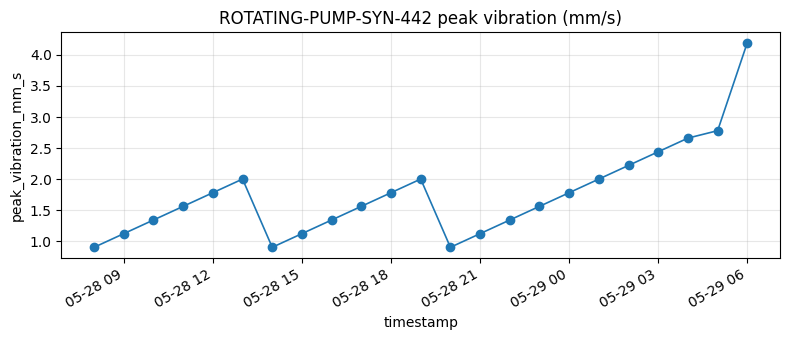

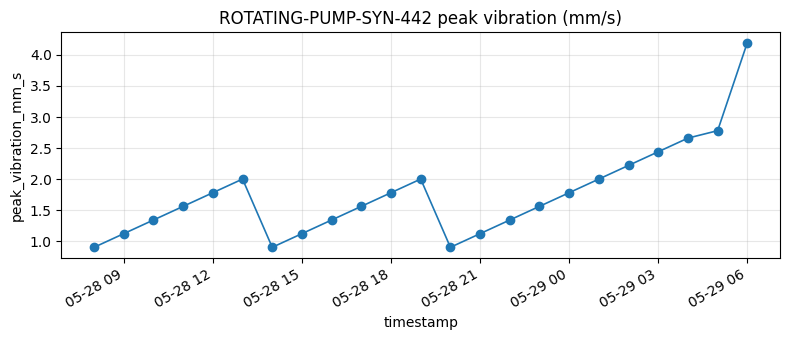

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(vibration_frame['timestamp'], vibration_frame['peak_vibration_mm_s'], marker='o', linewidth=1.2)
ax.set_title(f'ROTATING-PUMP-SYN-442 peak vibration (mm/s)')
ax.set_xlabel('timestamp')
ax.set_ylabel('peak_vibration_mm_s')
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
print('saved_figure=peak_vibration_timeseries_ROTATING-PUMP-SYN-442')
fig


## Row-level diagnosis

Diagnosis uses the **single highest peak** row from the loaded frame, not aggregate `describe()` on normal-operating rows alone.


In [8]:
worst_row = vibration_frame.loc[vibration_frame['peak_vibration_mm_s'].idxmax()]
print(f'asset_id={asset_id}')
print(f'diagnosed_failure_mode={worst_row["failure_mode"]}')
print(f'peak_vibration_mm_s={worst_row["peak_vibration_mm_s"]:.1f}')
print(f'bearing_temp_c={worst_row["bearing_temp_c"]:.1f}')
print(f'event_timestamp={worst_row["timestamp"]}')


asset_id=ROTATING-PUMP-SYN-442
diagnosed_failure_mode=bearing_wear
peak_vibration_mm_s=4.2
bearing_temp_c=61.4
event_timestamp=2026-05-29 06:00:00+00:00


## Conclusion

For **`ROTATING-PUMP-SYN-442`**, the final hourly sample in `sensor_readings_SYN-442.csv` shows elevated peak velocity (`diagnosed_failure_mode=bearing_wear`, `peak_vibration_mm_s=4.2` mm/s). Schedule bearing inspection. Dataset-wide max from normal-only `describe()` (~2.78 mm/s) understates the failure row.
